### Threshold Theory vs SDT
Run the cell.

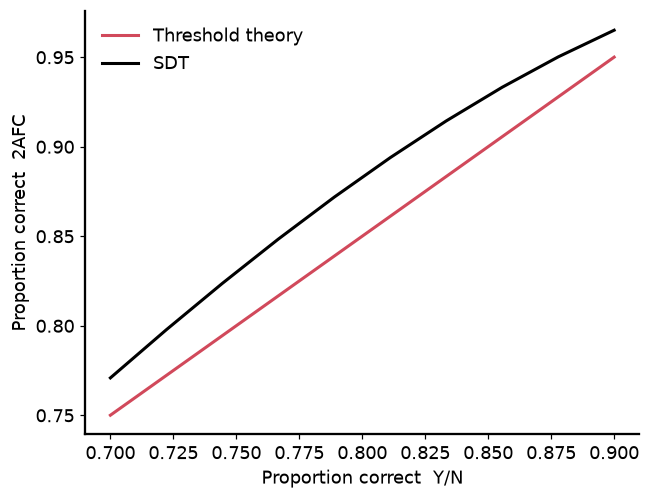

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"
SIGNAL = "#d1495b"
CRIT   = "#333333"

from scipy.stats import norm

# --- Under Threshold Theory (the "quick and dirty" way) ---
p_yes_signalpresent = np.linspace(0.5, 0.9, 10)   # proportion of signals detected
p_yes_signalabsent  = 0.1                          # guesses "yes" on some absent trials

tt_pc_yn   = p_yes_signalpresent * 0.5 + (1 - p_yes_signalabsent) * 0.5
# on undetected trials the 2AFC observer is left guessing between two "absent" intervals
tt_pc_2afc = p_yes_signalpresent + 0.5 * (1 - p_yes_signalpresent)

# --- The theoretical relationship under SDT (unbiased observer) ---
pc_yn_sdt   = np.linspace(0.7, 0.9, 10)
pc_2afc_sdt = norm.cdf(2 * norm.ppf(pc_yn_sdt) / np.sqrt(2))

plt.figure(figsize=(6.5, 5))
plt.plot(tt_pc_yn,  tt_pc_2afc,  color=SIGNAL, lw=2, label="Threshold theory")
plt.plot(pc_yn_sdt, pc_2afc_sdt, color="k",    lw=2, label="SDT")
plt.xlabel("Proportion correct  Y/N")
plt.ylabel("Proportion correct  2AFC")
plt.legend(loc="upper left")
plt.show()
